#**Exercise 1 : (1,2)**

In [1]:
# First, download and extract Minotaur binaries
!rm -rfv mbin minotaur-0.4.1-linux-x86_64 minotaur-nightly
!wget -nc https://www.ieor.iitb.ac.in/files/faculty/amahajan/minotaur/bin/minotaur-nightly.tar.gz
!tar -zxf minotaur-nightly.tar.gz
!ln -s minotaur-nightly mbin

!pip install -q pyomo

--2025-09-24 17:22:17--  https://www.ieor.iitb.ac.in/files/faculty/amahajan/minotaur/bin/minotaur-nightly.tar.gz
Resolving www.ieor.iitb.ac.in (www.ieor.iitb.ac.in)... 103.21.125.143
Connecting to www.ieor.iitb.ac.in (www.ieor.iitb.ac.in)|103.21.125.143|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 81909688 (78M) [application/x-gzip]
Saving to: ‘minotaur-nightly.tar.gz’

minotaur-nightly.ta 100%[===================>]  78.11M  12.6MB/s    in 7.7s    

2025-09-24 17:22:26 (10.2 MB/s) - ‘minotaur-nightly.tar.gz’ saved [81909688/81909688]



In [2]:
from pyomo.environ import *
from pyomo.opt import SolverFactory

A = (-5.0, 0.0); B = (0.0, 10.0); C = (5.0, 0.0); P = (5.0, 10.0)

model = ConcreteModel()
model.x = Var(domain=Reals)
model.y = Var(domain=Reals)
model.lam = Var(range(1,4), domain=NonNegativeReals, bounds=(0,1))
model.sumlam = Constraint(expr = sum(model.lam[i] for i in model.lam) == 1.0)
model.constr_x = Constraint(expr = model.x == model.lam[1]*A[0] + model.lam[2]*B[0] + model.lam[3]*C[0])
model.constr_y = Constraint(expr = model.y == model.lam[1]*A[1] + model.lam[2]*B[1] + model.lam[3]*C[1])
model.obj = Objective(expr = (model.x - P[0])**2 + (model.y - P[1])**2, sense=minimize)


solver = SolverFactory('mglob', executable='./mbin/mglob')
solver.options['--time_limit'] = 30
res = solver.solve(model, tee=False)


x_opt = model.x.value; y_opt = model.y.value
print("Optimal x,y =", x_opt, y_opt)
print("Distance =", ((x_opt-P[0])**2 + (y_opt-P[1])**2)**0.5)



Optimal x,y = 0.9999999999999998 8.0
Distance = 4.47213595499958


#**Exercise 2 : (1,2,3)**

Rectangle dimensions: l = 21.85660149905561 , b = 32.26231542327972
Circle 1: center=(11.856584285813595, 9.999999890000074), radius=10.0
Circle 2: center=(15.856601559055301, 25.491928732264068), radius=6.0
Circle 3: center=(5.000003124127456, 27.262315473279262), radius=5.0
Circle 4: center=(2.9999999670003104, 19.51634963734318), radius=3.0


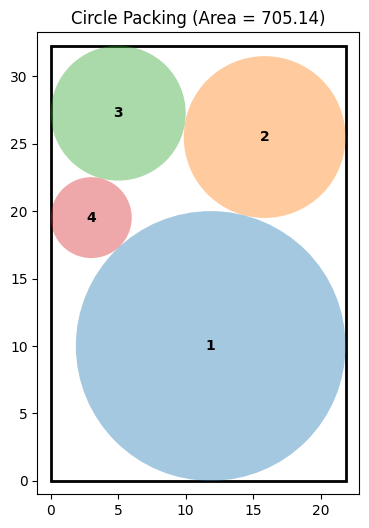

In [3]:
from pyomo.environ import *

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

# Data
r = {1:10.0, 2:6.0, 3:5.0, 4:3.0}
n = len(r)

model = ConcreteModel()
model.l = Var(domain=NonNegativeReals)   # rectangle length
model.b = Var(domain=NonNegativeReals)   # rectangle breadth
model.x = Var(range(1,n+1), domain=Reals)
model.y = Var(range(1,n+1), domain=Reals)

# Objective: minimize area
model.obj = Objective(expr = model.l * model.b, sense=minimize)

# Containment constraints
model.contain = ConstraintList()
for i in range(1,n+1):
    model.contain.add(model.x[i] >= r[i])
    model.contain.add(model.y[i] >= r[i])
    model.contain.add(model.x[i] <= model.l - r[i])
    model.contain.add(model.y[i] <= model.b - r[i])

# Non-overlap constraints (quadratic)
model.nonover = ConstraintList()
for i in range(1,n+1):
    for j in range(i+1, n+1):
        model.nonover.add((model.x[i]-model.x[j])**2 + (model.y[i]-model.y[j])**2 >= (r[i] + r[j])**2)


mntr = SolverFactory("mglob", executable="./mbin/mglob")
mntr.options['--time_limit'] = 600
mntr.options['--log_level'] = 3
result = mntr.solve(model, tee=False)

print("Rectangle dimensions: l =", model.l.value, ", b =", model.b.value)
for i in range(1, n+1):
    print(f"Circle {i}: center=({model.x[i].value}, {model.y[i].value}), radius={r[i]}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(6,6))
ax.set_aspect('equal', adjustable='box')

# Draw rectangle
ax.add_patch(Rectangle((0,0), model.l.value, model.b.value,
                       fill=False, linewidth=2))

# Draw circles
colors = ['tab:blue','tab:orange','tab:green','tab:red']
for i in range(1, n+1):
    xi, yi = model.x[i].value, model.y[i].value
    ci = Circle((xi, yi), r[i], facecolor=colors[i-1], alpha=0.4)
    ax.add_patch(ci)
    ax.text(xi, yi, f"{i}", ha='center', va='center',
            fontsize=10, color='black', weight='bold')

ax.set_xlim(-1, model.l.value+1)
ax.set_ylim(-1, model.b.value+1)
ax.set_title(f"Circle Packing (Area = {model.l.value*model.b.value:.2f})")
plt.show()


#**Exercise 3 : (1,2,3,4)**

In [ ]:
import pandas as pd
from pyomo.environ import ConcreteModel, Var, Objective, Constraint, RangeSet, NonNegativeReals, Binary, minimize, maximize, value
from pyomo.opt import SolverFactory, TerminationCondition

# Load the data (assuming portfolio.csv is available)
# Note: The delimiter might need to be adjusted based on the actual file format
portfolio_df = pd.read_csv('portfolio.csv', sep=';')

# Define the number of stocks and budget
n = len(portfolio_df)
budget = 1
max_stocks = 5

# Define the Pyomo model
model_max_return = ConcreteModel()

# Define the set for stocks
model_max_return.stocks = RangeSet(n)

# Define decision variables
model_max_return.invest = Var(model_max_return.stocks, within=NonNegativeReals)  # Investment amount in each stock
model_max_return.select = Var(model_max_return.stocks, within=Binary)           # Binary variable for stock selection

# Define the objective function: Maximize total expected return
model_max_return.obj = Objective(expr=sum(model_max_return.invest[i] * portfolio_df['AVG'][i-1] for i in model_max_return.stocks), sense=maximize)

# Add a constraint for the total investment budget
model_max_return.budget_constraint = Constraint(expr=sum(model_max_return.invest[i] for i in model_max_return.stocks) <= budget)

# Add a constraint to limit the number of selected stocks
model_max_return.stock_selection_constraint = Constraint(expr=sum(model_max_return.select[i] for i in model_max_return.stocks) <= max_stocks)

# Add linking constraints: invest[i] > 0 only if select[i] = 1
# A large number M is needed for the big-M formulation
M = budget # A sufficiently large number, budget is an upper bound for invest
def linking_rule(model, i):
  return model.invest[i] <= M * model_max_return.select[i]
model_max_return.linking_constraint = Constraint(model_max_return.stocks, rule=linking_rule)

# Solve the model
# Assuming 'glpk' is available and in the PATH or specify the executable path
solver = SolverFactory('glpk', executable='/usr/bin/glpsol')
result_max_return = solver.solve(model_max_return, tee=True)

# Print solver results
print("\nSolver Results:")
print(f"Termination Condition: {result_max_return.solver.termination_condition}")
print(f"Solver Status: {result_max_return.solver.status}")

if result_max_return.solver.termination_condition == TerminationCondition.optimal:
    print("\nOptimal Portfolio Allocation (ignoring variance):")
    total_return = 0
    selected_stocks_count = 0
    print("Stock | Investment | Selected")
    print("------|------------|----------")
    for i in model_max_return.stocks:
        investment = value(model_max_return.invest[i])
        selected = value(model_max_return.select[i])
        # Only print if investment is non-zero or stock is selected
        if investment > 1e-6 or selected > 0.5:
            print(f"{portfolio_df['#NAME'][i-1]} | {investment:.4f}   | {int(selected)}")
            total_return += investment * portfolio_df['AVG'][i-1]
            if selected > 0.5: # Check if the stock was selected (binary variable is close to 1)
                selected_stocks_count += 1

    print(f"\nTotal Expected Return: {value(model_max_return.obj):.4f}")
    print(f"Number of stocks selected: {selected_stocks_count}")
else:
    print("\nSolver did not find an optimal solution.")
    print("Please check the solver output for details.")

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmpkj7o6ge7.glpk.raw --wglp /tmp/tmpk6cs8cjw.glpk.glp --cpxlp
 /tmp/tmpl0o27p6a.pyomo.lp
Reading problem data from '/tmp/tmpl0o27p6a.pyomo.lp'...
/tmp/tmpl0o27p6a.pyomo.lp:216: warning: lower bound of variable 'x24' redefined
/tmp/tmpl0o27p6a.pyomo.lp:216: warning: upper bound of variable 'x24' redefined
22 rows, 40 columns, 80 non-zeros
20 integer variables, all of which are binary
236 lines were read
Writing problem data to '/tmp/tmpk6cs8cjw.glpk.glp'...
207 lines were written
GLPK Integer Optimizer 5.0
22 rows, 40 columns, 80 non-zeros
20 integer variables, all of which are binary
Preprocessing...
22 rows, 40 columns, 80 non-zeros
20 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 22
Solving LP relaxation...
GLPK Simplex Optimizer

### Formulate Model with Risk (Variance) Constraint

EX3-2

In [ ]:
print("Mathematical Model for Portfolio Optimization with Variance Constraint:")

print("\nDecision Variables:")
print("  invest_i: Proportion of the total budget invested in stock i (continuous, 0 <= invest_i <= 1, for i = 1 to n)")
print("  select_i: Binary variable, 1 if stock i is selected, 0 otherwise (for i = 1 to n)")


print("\nObjective Function:")
print("Maximize the expected return of the portfolio:")
print("  Maximize: Sum(invest_i * μ_i for i = 1 to n)")
print("  where μ_i is the average rate of return for stock i.")

print("\nConstraints:")
print("1. Total budget constraint:")
print("   Sum(invest_i for i = 1 to n) <= Budget")
print("   (In this problem, Budget = 1)")

print("2. Stock selection constraint:")
print("   Sum(select_i for i = 1 to k) <= max_stocks")
print("   (In this problem, max_stocks = 5)")


print("3. Linking constraints:")
print("   invest_i <= select_i  (for i = 1 to n)")
print("   (Ensures that investment in stock i is only possible if stock i is selected. Since invest_i is a proportion of the budget, which is 1, the upper bound for invest_i is also 1, so a large M is not explicitly needed here if invest_i is defined as a proportion).")


print("4. Portfolio variance constraint:")
print("   Sum(Sum(invest_i * invest_j * Cov(i, j) for j = 1 to n) for i = 1 to n) <= θ")
print("   where Cov(i, j) is the covariance between the returns of stock i and stock j.")
print("   Note: If only variances (σ_i^2) are provided and covariances are assumed to be zero, the constraint simplifies to:")
print("   Sum(invest_i^2 * σ_i^2 for i = 1 to n) <= θ")
print("   In this problem, only variances are given, so we will use the simplified form assuming zero covariance between different stocks.")

print("\nNote: This model is a Quadratic Programming (QP) problem if using the simplified variance constraint or a Quadratic Constrained Quadratic Programming (QCQP) problem if using the full covariance matrix, combined with integer variables (select_i), making it a Mixed-Integer Quadratic Program (MIQP) or Mixed-Integer Quadratically Constrained Quadratic Program (MIQCQP).")

Mathematical Model for Portfolio Optimization with Variance Constraint:

Decision Variables:
  invest_i: Proportion of the total budget invested in stock i (continuous, 0 <= invest_i <= 1, for i = 1 to n)
  select_i: Binary variable, 1 if stock i is selected, 0 otherwise (for i = 1 to n)

Objective Function:
Maximize the expected return of the portfolio:
  Maximize: Sum(invest_i * μ_i for i = 1 to n)
  where μ_i is the average rate of return for stock i.

Constraints:
1. Total budget constraint:
   Sum(invest_i for i = 1 to n) <= Budget
   (In this problem, Budget = 1)
2. Stock selection constraint:
   Sum(select_i for i = 1 to k) <= max_stocks
   (In this problem, max_stocks = 5)
3. Linking constraints:
   invest_i <= select_i  (for i = 1 to n)
   (Ensures that investment in stock i is only possible if stock i is selected. Since invest_i is a proportion of the budget, which is 1, the upper bound for invest_i is also 1, so a large M is not explicitly needed here if invest_i is defined 

In [ ]:
!apt-get install -y -qq coinor-cbc

In [ ]:
!which cbc

EX-3-3

In [ ]:
from pyomo.environ import ConcreteModel, Var, Objective, Constraint, RangeSet, NonNegativeReals, Binary, minimize, maximize, value
from pyomo.opt import SolverFactory, TerminationCondition
import pandas as pd

# Load the data (assuming portfolio.csv is available)
# Note: The delimiter might need to be adjusted based on the actual file format
portfolio_df = pd.read_csv('portfolio.csv', sep=';')

# Define the number of stocks, budget and max_stocks
n = len(portfolio_df)
budget = 1
max_stocks = 5

# Define the Pyomo model with variance constraint
model_variance = ConcreteModel()

# Define the set for stocks
model_variance.stocks = RangeSet(n)

# Define decision variables
model_variance.invest = Var(model_variance.stocks, within=NonNegativeReals)  # Investment proportion in each stock
model_variance.select = Var(model_variance.stocks, within=Binary)           # Binary variable for stock selection

# Define the objective function: Maximize total expected return
model_variance.obj = Objective(expr=sum(model_variance.invest[i] * portfolio_df['AVG'][i-1] for i in model_variance.stocks), sense=maximize)

# Add a constraint for the total investment budget
model_variance.budget_constraint = Constraint(expr=sum(model_variance.invest[i] for i in model_variance.stocks) <= budget)

# Add a constraint to limit the number of selected stocks
model_variance.stock_selection_constraint = Constraint(expr=sum(model_variance.select[i] for i in model_variance.stocks) <= max_stocks)

# Add linking constraints: invest[i] > 0 only if select[i] = 1
# Since invest is a proportion of budget=1, invest[i] <= 1. select[i] is binary (0 or 1).
# invest[i] <= select[i] is sufficient as a linking constraint.
def linking_rule_variance(model, i):
  return model_variance.invest[i] <= model_variance.select[i]
model_variance.linking_constraint = Constraint(model_variance.stocks, rule=linking_rule_variance)

# Add the portfolio variance constraint (assuming zero covariance between stocks)
theta = 0.3 # Variance threshold
model_variance.variance_constraint = Constraint(expr=sum(model_variance.invest[i]**2 * portfolio_df['VARIANCE'][i-1] for i in model_variance.stocks) <= theta)


# Solve the model using minotaur's mglob solver
mntr = SolverFactory("mglob", executable='./mbin/mglob')
# Optional: Add solver options if needed (e.g., time limit, logging level)
mntr.options['--log_level'] = 2
mntr.options['--time_limit'] = 60 # Set a time limit

result_variance = mntr.solve(model_variance, tee=True)

# Print solver results
print("\nSolver Results:")
print(f"Termination Condition: {result_variance.solver.termination_condition}")
print(f"Solver Status: {result_variance.solver.status}")

if result_variance.solver.termination_condition == TerminationCondition.optimal:
    print("\nOptimal Portfolio Allocation (with variance constraint):")
    total_return_variance = 0
    selected_stocks_count_variance = 0
    print("Stock | Investment | Selected")
    print("------|------------|----------")
    for i in model_variance.stocks:
        investment_variance = value(model_variance.invest[i])
        selected_variance = value(model_variance.select[i])
        # Only print if investment is non-zero or stock is selected
        if investment_variance > 1e-6 or selected_variance > 0.5:
            print(f"{portfolio_df['#NAME'][i-1]} | {investment_variance:.4f}   | {int(selected_variance)}")
            total_return_variance += investment_variance * portfolio_df['AVG'][i-1]
            if selected_variance > 0.5: # Check if the stock was selected
                selected_stocks_count_variance += 1

    print(f"\nTotal Expected Return: {value(model_variance.obj):.4f}")
    print(f"Number of stocks selected: {selected_stocks_count_variance}")
    print(f"Portfolio Variance: {sum(value(model_variance.invest[i])**2 * portfolio_df['VARIANCE'][i-1] for i in model_variance.stocks):.4f}")

else:
    print("\nSolver did not find an optimal solution.")
    print("Please check the solver output for details.")

Environment: User provided options:
  problem_file = /tmp/tmpqxwtt5l6.pyomo.nl
  ampl = 1
  log_level = 2
  time_limit = 60
Environment: End of user provided options.

mntr-glob: Minotaur version 0.4 patch 1 git revision v0.4-170-gc41e273
mntr-glob: global optimization for nonconvex QCQP
Environment: User provided options:
  log_level = 2
  time_limit = 60
Environment: End of user provided options.

AMPLInterface: reading .nl file /tmp/tmpqxwtt5l6.pyomo.nl
AMPLInterface: problem type is MIQCQP
AMPLInterface: time used in reading file = 0.00 seconds.
Solver: time used in reading instance = 0.00
mntr-glob: objective sense: maximize (will be converted to Minimize)
Presolver: Presolving ... 
Presolver: Finished presolving.
mntr-glob: handlers used in transformer: 
  IntVarHandler (Handling integrality of variables).
  LinearHandler (Handling linear constraints)
mntr-glob: All constraints and objective found to be convex
Problem is forwarded to QG - convex MINLP solver
QG: Using quadratic f

In [ ]:
!which glpk

EX3-4

/tmp/ipython-input-3007193929.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


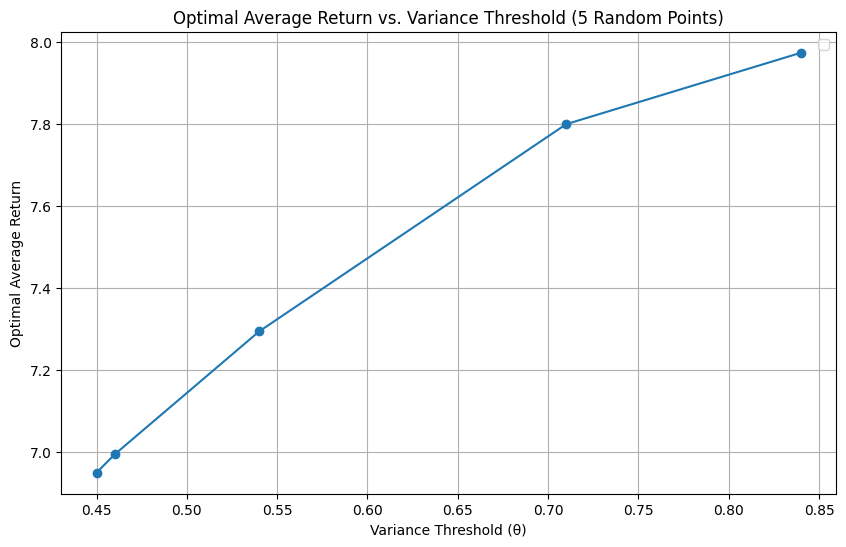


Solver Termination Conditions for each theta:
Theta = 0.4500: optimal
Theta = 0.4600: optimal
Theta = 0.5400: optimal
Theta = 0.7100: optimal
Theta = 0.8400: optimal

Selected Theta Values: [0.45 0.46 0.54 0.71 0.84]


In [ ]:
from pyomo.environ import ConcreteModel, Var, Objective, Constraint, RangeSet, NonNegativeReals, Binary, minimize, maximize, value
from pyomo.opt import SolverFactory, TerminationCondition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data (assuming portfolio.csv is available)
portfolio_df = pd.read_csv('portfolio.csv', sep=';')

# Define the number of stocks, budget and max_stocks
n = len(portfolio_df)
budget = 1
max_stocks = 5

# Define a range of theta values to explore and select 5 random values
# Let's select 5 random values from the range used previously (0.01 to 1.0)
np.random.seed(42) # Set a seed for reproducibility of random selection
all_theta_values = np.linspace(0.01, 1.0, 100) # Use a larger range to select from
theta_values = np.random.choice(all_theta_values, 5, replace=False) # Select 5 unique random values
theta_values = np.sort(theta_values) # Sort the values for a cleaner plot

# Lists to store the results
average_returns = []
portfolio_variances = []
termination_conditions = []

# Solve the model for each theta value
for theta in theta_values:
    # Define the Pyomo model with variance constraint
    model_variance = ConcreteModel()

    # Define the set for stocks
    model_variance.stocks = RangeSet(n)

    # Define decision variables
    model_variance.invest = Var(model_variance.stocks, within=NonNegativeReals)
    model_variance.select = Var(model_variance.stocks, within=Binary)

    # Define the objective function: Maximize total expected return
    model_variance.obj = Objective(expr=sum(model_variance.invest[i] * portfolio_df['AVG'][i-1] for i in model_variance.stocks), sense=maximize)

    # Add a constraint for the total investment budget
    model_variance.budget_constraint = Constraint(expr=sum(model_variance.invest[i] for i in model_variance.stocks) <= budget)

    # Add a constraint to limit the number of selected stocks
    model_variance.stock_selection_constraint = Constraint(expr=sum(model_variance.select[i] for i in model_variance.stocks) <= max_stocks)

    # Add linking constraints
    def linking_rule_variance(model, i):
      return model_variance.invest[i] <= model_variance.select[i]
    model_variance.linking_constraint = Constraint(model_variance.stocks, rule=linking_rule_variance)

    # Add the portfolio variance constraint with the current theta value
    model_variance.variance_constraint = Constraint(expr=sum(model_variance.invest[i]**2 * portfolio_df['VARIANCE'][i-1] for i in model_variance.stocks) <= theta)

    # Solve the model using minotaur's mglob solver
    # Using the executable path that worked previously in cell 245bdff0
    mntr = SolverFactory("mglob", executable='./mbin/mglob')
    # Keep solver options consistent, but disable tee=True for cleaner loop output
    mntr.options['--log_level'] = 0 # Reduce logging level for cleaner output
    mntr.options['--time_limit'] = 60

    result_variance = mntr.solve(model_variance, tee=False) # Disable tee for loop

    # Store the results
    termination_conditions.append(result_variance.solver.termination_condition)
    if result_variance.solver.termination_condition == TerminationCondition.optimal:
        average_returns.append(value(model_variance.obj))
        # Calculate and store portfolio variance for verification
        portfolio_variance = sum(value(model_variance.invest[i])**2 * portfolio_df['VARIANCE'][i-1] for i in model_variance.stocks)
        portfolio_variances.append(portfolio_variance)
    else:
        # Store NaN or a marker for cases where the solver didn't find an optimal solution
        average_returns.append(np.nan)
        portfolio_variances.append(np.nan)


# --- Plot the results ---

plt.figure(figsize=(10, 6))
plt.plot(theta_values, average_returns, marker='o', linestyle='-')

# Highlight points where the solver did not find an optimal solution (optional)
failed_indices = [i for i, cond in enumerate(termination_conditions) if cond != TerminationCondition.optimal]
if failed_indices:
    plt.plot(theta_values[failed_indices], [average_returns[i] for i in failed_indices], 'rx', markersize=10, label='Solver Failed')


plt.xlabel('Variance Threshold (θ)')
plt.ylabel('Optimal Average Return')
plt.title('Optimal Average Return vs. Variance Threshold (5 Random Points)')
plt.grid(True)
plt.legend()
plt.show()

# Optional: Print termination conditions for review
print("\nSolver Termination Conditions for each theta:")
for i, (theta, cond) in enumerate(zip(theta_values, termination_conditions)):
    print(f"Theta = {theta:.4f}: {cond}")

print("\nSelected Theta Values:", theta_values)